# Business Expansion Analysis
This notebook performs an inferential analysis to determine the most favorable countries for business expansion based on economic indicators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

# Load the dataset
df = pd.read_csv("Prepared_Global_Economy_Indicators.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 12 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Country                                                         212 non-null    object 
 1   Population                                                      212 non-null    float64
 2   Per capita GNI                                                  212 non-null    float64
 3   Gross National Income(GNI) in USD                               212 non-null    float64
 4   Gross Domestic Product (GDP)                                    212 non-null    float64
 5   Agriculture, hunting, forestry, fishing (ISIC A-B) (%)          209 non-null    float64
 6   Manufacturing (ISIC D) (%)                                      212 non-null    float64
 7   Mining, Manufacturing, Utilities (ISIC C-E) (%)      

## Option 1: Regress Sectoral Features to Predict Per Capita GNI

In [2]:
sector_features = [
    'Manufacturing (ISIC D) (%)',
    'Mining, Manufacturing, Utilities (ISIC C-E) (%)',
    'Other Activities (ISIC J-P) (%)',
    'Transport, storage and communication (ISIC I) (%)',
    'Wholesale, retail trade, restaurants and hotels (ISIC G-H) (%)',
    'Construction (ISIC F) (%)'
]

target_option1 = 'Per capita GNI'
df_opt1 = df[sector_features + [target_option1]].dropna()
scaler = StandardScaler()
X_opt1 = scaler.fit_transform(df_opt1[sector_features])
y_opt1 = df_opt1[target_option1]
X_opt1_sm = sm.add_constant(X_opt1)
model_opt1 = sm.OLS(y_opt1, X_opt1_sm).fit()
model_opt1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Per capita GNI   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     20.74
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           6.11e-19
Time:                        14:12:47   Log-Likelihood:                -2406.1
No. Observations:                 212   AIC:                             4826.
Df Residuals:                     205   BIC:                             4850.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.696e+04   1435.106     11.817      0.000    1.41e+04    1.98e+04
x1          4190.1838   1767.061      2.371      0.019     706.240    7674.128
x2          2882.9457   1988.855      1.450      0.149   -1038.288    6804.179
x3          1.728e+04   1640.098     10.533      0.000     1.4e+04    2.05e+04
x4           916.1312   1472.987      0.622      0.535   -1988.015    3820.277
x5           731.2792   1599.746      0.457      0.648   -2422.786    3885.344
x6          2333.1520   1473.461      1.583      0.115    -571.928    5238.232
==============================================================================
Omnibus:                      199.953   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4724.880
Skew:                           3.606   Prob(JB):                         0.00
Kurtosis:                      24.975   Cond. No.                         2.38
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Visualize Coefficients and Confidence Intervals

C:\Users\Kamal_FOM\AppData\Local\Temp\ipykernel_22924\4226098171.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=regression_df_opt1, x='Coefficient', y='Feature', join=False, color='blue')


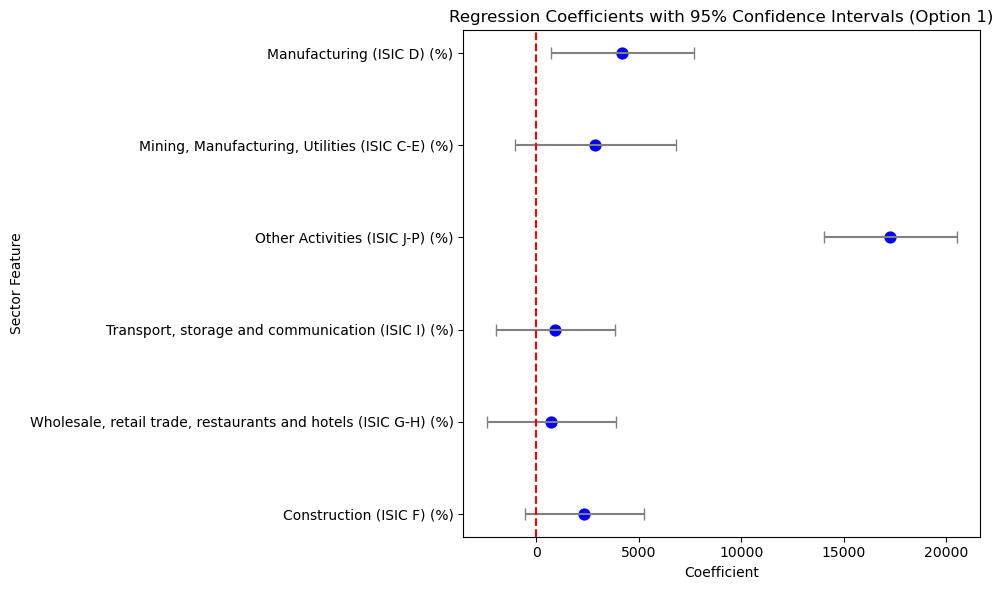

In [3]:
coeffs_opt1 = model_opt1.params[1:]
conf_int_opt1 = model_opt1.conf_int().iloc[1:]
conf_int_opt1.columns = ['CI Lower', 'CI Upper']
pvals_opt1 = model_opt1.pvalues[1:]

regression_df_opt1 = pd.DataFrame({
    'Feature': sector_features,
    'Coefficient': coeffs_opt1,
    'P-Value': pvals_opt1,
    'CI Lower': conf_int_opt1['CI Lower'],
    'CI Upper': conf_int_opt1['CI Upper']
})

plt.figure(figsize=(10, 6))
sns.pointplot(data=regression_df_opt1, x='Coefficient', y='Feature', join=False, color='blue')
plt.errorbar(
    x=regression_df_opt1['Coefficient'],
    y=range(len(regression_df_opt1)),
    xerr=[
        regression_df_opt1['Coefficient'] - regression_df_opt1['CI Lower'],
        regression_df_opt1['CI Upper'] - regression_df_opt1['Coefficient']
    ],
    fmt='none',
    ecolor='gray',
    capsize=4
)
plt.axvline(0, color='red', linestyle='--')
plt.title('Regression Coefficients with 95% Confidence Intervals (Option 1)')
plt.xlabel('Coefficient')
plt.ylabel('Sector Feature')
plt.tight_layout()
plt.show()

## Predict Top Countries by GNI per Capita

In [4]:
X_top = sm.add_constant(X_opt1)
df_top = df_opt1.copy()
df_top['Predicted GNI per capita'] = model_opt1.predict(X_top)
df_top = df_top.join(df.loc[df_top.index, ['Country']])
top_countries_opt1 = df_top[['Predicted GNI per capita', 'Country']].sort_values(by='Predicted GNI per capita', ascending=False).head(15)
top_countries_opt1

,Predicted GNI per capita,Country
21,64611.175923,Bermuda
27,62344.257940,British Virgin Islands
36,57562.370133,Cayman Islands
112,48088.464484,Luxembourg
202,47042.229358,United States
124,45519.844263,Monaco
106,45235.288962,Lebanon
110,45232.898868,Liechtenstein
127,45065.016337,Montserrat
41,43558.556354,"China, Hong Kong SAR"


C:\Users\Kamal_FOM\AppData\Local\Temp\ipykernel_22924\4254975424.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


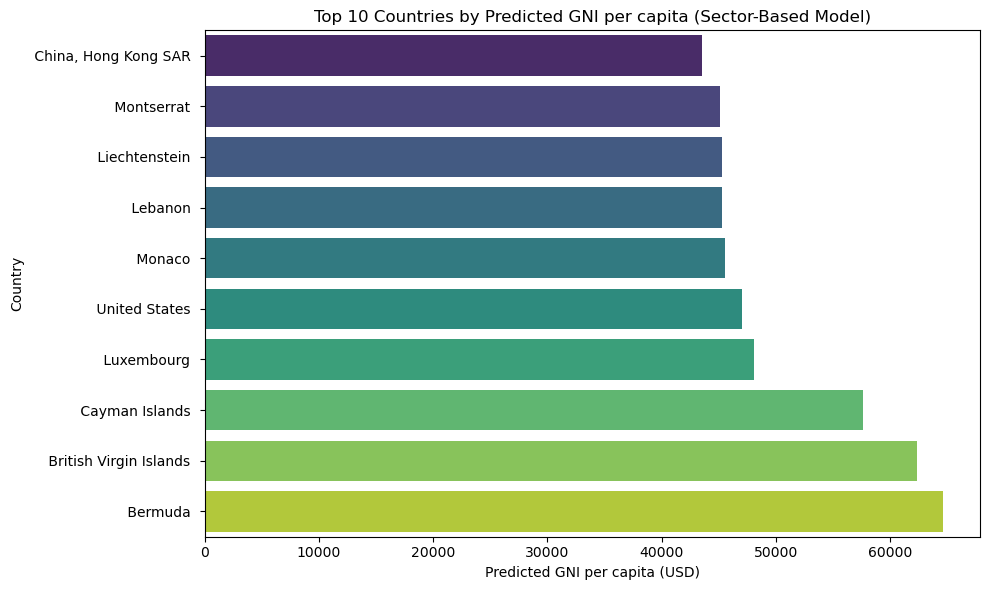

In [5]:
# Define top_10 from prediction results
top_10 = df_top[['Predicted GNI per capita']].join(df.loc[df_top.index, ['Country']])
top_10 = top_10.sort_values(by='Predicted GNI per capita', ascending=False).head(10)

# Now sort for horizontal bar chart
top_10_sorted = top_10.sort_values(by='Predicted GNI per capita', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_sorted,
    x='Predicted GNI per capita',
    y='Country',
    palette='viridis'
)
plt.title('Top 10 Countries by Predicted GNI per capita (Sector-Based Model)')
plt.xlabel('Predicted GNI per capita (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

C:\Users\Kamal_FOM\AppData\Local\Temp\ipykernel_22924\1882654504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


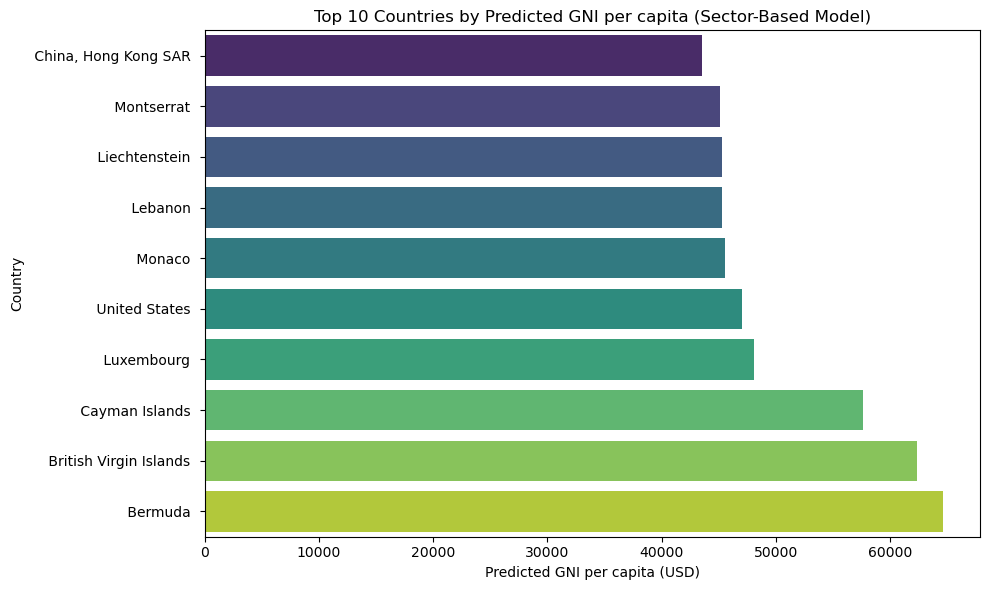

In [6]:
# Bar plot for top 10 countries by predicted GNI per capita
top_10_sorted = top_10.sort_values(by='Predicted GNI per capita', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_sorted,
    x='Predicted GNI per capita',
    y='Country',
    palette='viridis'
)
plt.title('Top 10 Countries by Predicted GNI per capita (Sector-Based Model)')
plt.xlabel('Predicted GNI per capita (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()